# Import

In [6]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib.pyplot as plt
import os 
import pandas as pd
import numpy as np
from pandas.api.types import CategoricalDtype
from ciim.src.utils.util import retrieve_net
from ciim.src.pathway_analysis.util import get_genesets, pathway_kde_func, get_hallmark, gsea_func, wrapper_gsea
from ciim.src.pathway_analysis.plots import plot_pathway_kde

# - plot
from ciim.src.feature_association.plots import heamap_plot_minor_cell_types

# plt.rcParams["figure.figsize"]=4,4
plt.rcParams["figure.dpi"]=150
# plt.rcParams["savefig.dpi"]=300
plt.rcParams["font.family"] = "Arial"

import warnings
warnings.filterwarnings("ignore")

# - dirs 
from ciim.src.common import PLOTS_DIR, SAVE_DIR,cell_types, \
     datasets_all, palette_datasets_pretty, palette_datasets, surrogate_names, \
     palette_treatment, colors_blind, palette_trend, palette_trend_2, palette_cell_types, palette_disease_effect

from ciim.src.feature_association.helper import retrieve_sig_net, calculate_tf_activity, retrieve_sig_stats, retrieve_stats_features

from ciim.src.feature_association.plots import plot_net_nx, plot_sig_tfs_stats, plot_analysis_and_centrality, plot_overlap
from ciim.src.utils.util import retrieve_adata, base_dir
from ciim.src.feature_association.helper import wrapper_tf_activity, wrapper_gene_expression, wrapper_association_with_age_condition
from ciim.src.feature_association.disease import plot_healthy_disease_trend
from ciim.src.feature_association.network import select_top_targets
import pandas as pd

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", None)
task_grn_inference_dir = '../../task_grn_inference'

# Aging TFs

In [11]:
!cd ../ && python src/feature_association/run_analysis.py --feature-type tf_activity --data-type bulk --analysis-mode multi-cohort
# !cd ../ && python src/experiments/post_aging_analysis.py --feature-type tf_activity


MULTI-COHORT AGING ANALYSIS
Feature: tf_activity
Traceback (most recent call last):
  File "/Users/jno24/Documents/projs/ongoing/ciim/src/feature_association/run_analysis.py", line 244, in <module>
    sys.exit(main())
  File "/Users/jno24/Documents/projs/ongoing/ciim/src/feature_association/run_analysis.py", line 234, in main
    run_multi_cohort_analysis(
  File "/Users/jno24/Documents/projs/ongoing/ciim/src/feature_association/run_analysis.py", line 119, in run_multi_cohort_analysis
    print(f"Datasets: {', '.join(args.datasets)}")
TypeError: can only join an iterable


# Aging hallmarks

In [4]:
# !cd ../ && python src/feature_association/script.py  --feature-type aging_hallmarks 
!cd ../ && python src/experiments/post_aging_analysis.py --feature-type aging_hallmarks

Saving figure to /vol/projects/jnourisa//output//plots//aging_hallmarks_by_geneset_B.png
Saving figure to /vol/projects/jnourisa//output//plots//aging_hallmarks_by_geneset_CD4T.png
Saving figure to /vol/projects/jnourisa//output//plots//aging_hallmarks_by_geneset_CD8T.png
Saving figure to /vol/projects/jnourisa//output//plots//aging_hallmarks_by_geneset_MONO.png
Saving figure to /vol/projects/jnourisa//output//plots//aging_hallmarks_by_geneset_NK.png


# Disease: SLE

In [65]:
if False: #tf_activity
    !cd ../ && bash scripts/experiment/run_condition_analysis.sh --dataset "SLE_European" --cell-types "CD4T CD8T" --data-type bulk --feature-type tf_activity
    !cd ../ && python src/experiments/post_condition_analysis.py --dataset "SLE_European" --analysis-type disease --data-type bulk --feature-type tf_activity --cell-types CD8T CD4T

In [75]:
if True: #aging_hallmarks
    # !cd ../ && bash scripts/experiment/run_condition_analysis.sh --dataset "SLE_European" --cell-types "CD4T CD8T" --data-type bulk --feature-type aging_hallmarks 
    !cd ../ && python src/experiments/post_condition_analysis.py --dataset "SLE_European" --analysis-type disease --data-type bulk --feature-type aging_hallmarks --cell-types CD8T CD4T --skip-pathway

Unified Condition Analysis - Disease
Dataset: SLE_European
Analysis type: disease
Data type: bulk
Feature type: aging_hallmarks
Output directory: /Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//plots/
Cell types: CD8T, CD4T
Significance threshold: 0.05
Total significant features per cell type:
cell_type
CD4T    214
CD8T    150
Name: gene, dtype: int64
Generating aging overlap plot...
  Processing cell type: CD8T
    Overlap with aging genes: 111
      Same direction: 108 (97.3%)
      Opposite direction: 1 (0.9%)
    Saved: /Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//plots/condition_aging_overlap_SLE_European_CD8T.png
  Processing cell type: CD4T
    Overlap with aging genes: 64
      Same direction: 57 (89.1%)
      Opposite direction: 7 (10.9%)
    Saved: /Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//plots/condition_aging_overlap_SLE_European_CD4T.png


# Perturbations

In [22]:
# !cd ../ && bash scripts/experiment/run_condition_analysis.sh --dataset op --cell-types "CD4T CD8T" --data-type bulk --feature-type tf_activity
# !cd ../ && python src/experiments/post_condition_analysis.py --dataset op --analysis-type perturbation --data-type bulk --feature-type tf_activity --cell-types CD4T CD8T --agreement opposite

!cd ../ && bash scripts/experiment/run_condition_analysis.sh --dataset CXCL9 --cell-types "CD4T" --data-type sc --feature-type tf_activity --skip-features
!cd ../ && python src/experiments/post_condition_analysis.py --dataset CXCL9 --analysis-type perturbation --data-type sc --feature-type tf_activity --cell-types CD4T --agreement opposite --skip-overview

# !cd ../ && bash scripts/experiment/run_condition_analysis.sh --dataset parsebioscience --cell-types "CD4T CD8T" --data-type bulk --feature-type tf_activity
# !cd ../ && python src/experiments/post_condition_analysis.py --dataset parsebioscience --analysis-type perturbation --data-type bulk --feature-type tf_activity --cell-types CD4T CD8T --agreement opposite

Condition Analysis (Unified)

Configuration:
  Dataset: CXCL9
  Cell types: CD4T
  Feature type: tf_activity
  Data type: sc
  Skip feature calculation: true


Running analysis...


CONDITION ANALYSIS: Ruxolitinib
Type: PERTURBATION
Dataset: CXCL9
Feature: tf_activity
Cell types: CD4T


[1/3] Skipping feature calculation (using cached data)

[2/3] Computing condition statistics (1 config(s))...
Association tf_activity with condition...
cell types: 100%|█████████████████████████████████| 1/1 [00:28<00:00, 28.24s/it]
['CD4T']
✓ Condition stats saved: /Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//stats/stats_CXCL9_sc_tf_activity_mixed-effect.csv

[3/3] Loading aging reference...
✓ Loaded 451 significant aging features

ANALYSIS COMPLETE


Results:
  Condition stats: /Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//stats/stats_CXCL9_sc_tf_activity_mixed-effect.csv
  Significant features: 414

SUCCESS: Analysis complete

Results saved to:
  base_folder/output/st

In [5]:
# !cd ../ && bash scripts/experiment/run_condition_analysis.sh --dataset op --cell-types "CD4T" --data-type sc --feature-type aging_hallmarks 
!cd ../ && python src/experiments/post_condition_analysis.py --dataset op --analysis-type perturbation --data-type sc --feature-type aging_hallmarks --cell-types CD4T --agreement opposite --skip-overview --skip-pathway

Unified Condition Analysis - Perturbation
Dataset: op
Analysis type: perturbation
Data type: sc
Feature type: aging_hallmarks
Output directory: /vol/projects/jnourisa//output//plots/
Cell types: CD4T
Significance threshold: 0.05
Total significant features per cell type:
cell_type
CD4T    98
CD8T     0
NK       0
B        0
MONO     0
Name: gene, dtype: int64
Generating aging overlap plot...
Traceback (most recent call last):
  File "/home/jnourisa/projs/ongoing/ciim/src/experiments/post_condition_analysis.py", line 1418, in <module>
    main()
  File "/home/jnourisa/projs/ongoing/ciim/src/experiments/post_condition_analysis.py", line 1410, in main
    plot_aging_overlap(
  File "/home/jnourisa/projs/ongoing/ciim/src/experiments/post_condition_analysis.py", line 247, in plot_aging_overlap
    aging_stats_sig = retrieve_sig_stats(type='bulk', feature_type=feature_type).drop_duplicates(subset=['cell_type', 'gene'])
  File "/home/jnourisa/projs/ongoing/ciim/src/feature_association/helper.p

In [ ]:
!cd ../ && bash scripts/experiment/run_condition_analysis.sh --dataset soundlife --cell-types "CD4T CD8T" --data-type metacell --feature-type tf_activity
# !cd ../ && python src/experiments/post_condition_analysis.py --dataset soundlife --analysis-type perturbation --data-type bulk --feature-type tf_activity --cell-types CD4T CD8T

Failed to connect to bus: No such file or directory


/home/jnourisa/.bashrc: line 60: cd: projs/ongoing/: No such file or directory
Condition Analysis (Unified)

Configuration:
  Dataset: soundlife
  Cell types: CD4T CD8T
  Feature type: tf_activity
  Data type: metacell
  Skip feature calculation: false


Running analysis...

usage: run_analysis.py [-h] --dataset DATASET
                       [--cell-types CELL_TYPES [CELL_TYPES ...]]
                       [--feature-type {tf_activity,gene_expression}]
                       [--data-type {bulk,sc}] [--skip-features]
                       [--association-type {spearman,pearson}]
run_analysis.py: error: argument --data-type: invalid choice: 'metacell' (choose from 'bulk', 'sc')


# Soundlife cohort

In [7]:
!cd ../ && bash scripts/experiment/run_condition_analysis.sh --dataset soundlife --cell-types "CD4T CD8T MONO" --data-type bulk --feature-type tf_activity

Condition Analysis (Unified)

Configuration:
  Dataset: soundlife
  Cell types: CD4T CD8T MONO
  Feature type: tf_activity
  Data type: bulk
  Skip feature calculation: false


Running analysis...


CONDITION ANALYSIS: Sound Life (Aging - All Samples)
Type: AGING
Dataset: soundlife
Feature: tf_activity
Cell types: CD4T, CD8T, MONO


[1/3] Calculating features...
Loading data...
Calculating TF activity...
  - Promotor-based only: False
soundlife bulk
cell types:   0%|                                         | 0/3 [00:00<?, ?it/s]... storing 'donor_age' as categorical
... storing 'dataset' as categorical
cell types:  33%|███████████                      | 1/3 [00:02<00:04,  2.21s/it]... storing 'donor_age' as categorical
... storing 'dataset' as categorical
cell types:  67%|██████████████████████           | 2/3 [00:06<00:03,  3.56s/it]... storing 'donor_age' as categorical
... storing 'dataset' as categorical
cell types: 100%|█████████████████████████████████| 3/3 [00:17<00:00,  5.71s/i

In [9]:
!cd ../ && python src/experiments/post_condition_analysis.py \
  --dataset soundlife \
  --config-label aging_all \
  --analysis-type aging \
  --data-type bulk \
  --feature-type tf_activity \
  --cell-types CD4T CD8T MONO

Unified Condition Analysis - Aging
Dataset: soundlife
Config label: aging_all
Analysis type: aging
Data type: bulk
Feature type: tf_activity
Output directory: /Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//plots/
Cell types: CD4T, CD8T, MONO
Significance threshold: 0.05
Loading config: aging_all
Total significant features per cell type:
cell_type
CD4T     33
CD8T    184
MONO      1
Name: gene, dtype: int64
Generating overview heatmap...
  Saved: /Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//plots/overview_soundlife.png
Generating aging overlap plot...
cell_type  condition     
CD4T       Older (55-65y)     33
CD8T       Older (55-65y)    184
MONO       Older (55-65y)      1
Name: gene, dtype: int64
  Processing cell type: CD4T
    Overlap with aging genes: 30
      Same direction: 30 (100.0%)
      Opposite direction: 0 (0.0%)
    Saved: /Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//plots/condition_aging_overlap_soundlife_CD4T.png
  Proces

# IBD

In [29]:
{base_dir}

{'/Users/jno24/Documents/projs/ongoing/ciim/base_folder'}

In [28]:
!file /Users/jno24/Documents/projs/ongoing/ciim/base_folder/datasets/bulk/ibd_bulk.h5ad

/Users/jno24/Documents/projs/ongoing/ciim/base_folder/datasets/bulk/ibd_bulk.h5ad: Hierarchical Data Format (version 5) data


python(68561) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


# Trajectory plot: TF acitvity with age


(981, 119)
(313, 279)
(61, 267)
(150, 113)
(981,) (981,) (981,)
(313,) (313,) (313,)
(61,) (61,) (61,)
(150,) (150,) (150,)


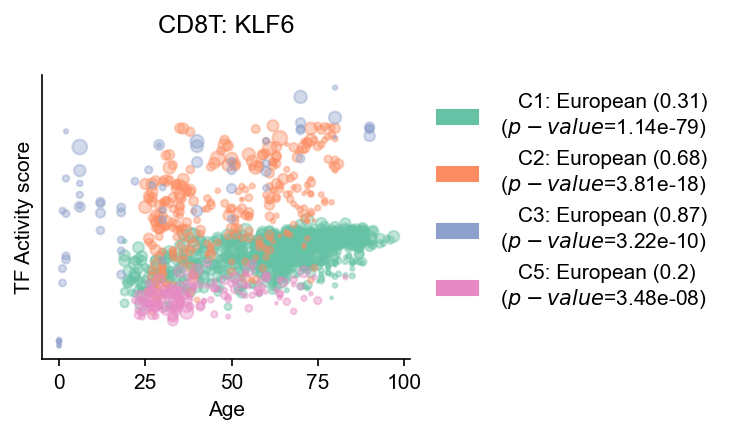

In [ ]:

from ciim.src.feature_association.plots import plot_trends
from ciim.src.common import palette_datasets, datasets_e
if True:
    datasets = datasets_e
    # # - load data
    if True:
        cell_type = 'CD8T'
        adata_complete = {dataset: retrieve_adata(dataset) for dataset in datasets}
        adata_dict = {dataset: adata[adata.obs['cell_type'] == cell_type] for dataset, adata in adata_complete.items()}
        nets_dict = {dataset: retrieve_net(dataset, cell_type) for dataset in datasets}
        tf_acts_dict = {}
        for dataset in datasets:
            tf_acts = calculate_tf_activity(adata_dict[dataset], nets_dict[dataset])
            print(tf_acts.shape)
            tf_acts_dict[surrogate_names[dataset]] = tf_acts

    cell_type = 'CD8T'
    genes = ['KLF6']
    
    plot_trends(top_tfs=genes, datasets=[surrogate_names[d] for d in datasets], data_dict=tf_acts_dict, palette=palette_datasets_pretty, cell_type=cell_type, surrogate_names=surrogate_names)
    plt.yticks([])
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/tf_activity/trends_{cell_type}_case.png', dpi=300)

# TF activity trend vs expression trend in aging


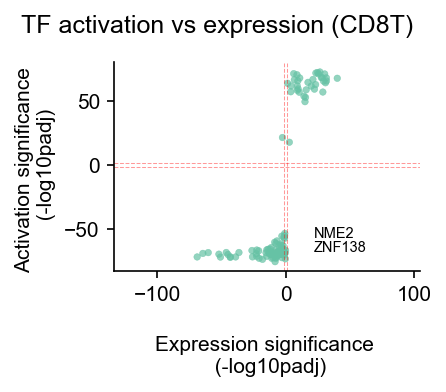

In [ ]:
from ciim.src.feature_association.plots import plot_activation_vs_expression

cell_type = 'CD8T'
os.makedirs(PLOTS_DIR, exist_ok=True)
stats_tfs = retrieve_sig_stats()
stats_targets = retrieve_sig_stats(feature_type='gene_expression')
stats_all = stats_tfs[['cell_type', 'tf', 'slope', 'p_value_adj', 'dataset']].merge(
    stats_targets[['cell_type', 'target', 'slope', 'p_value_adj', 'dataset']],
    left_on=['cell_type', 'tf', 'dataset'],
    right_on=['cell_type', 'target', 'dataset'],
    how='inner',
    suffixes=('_source', '_target')
)
stats_all = stats_all[stats_all['dataset'].isin(['data1'])]
stats_all['Activation significance'] = np.sign(stats_all['slope_source']) * -np.log10(stats_all['p_value_adj_source'].clip(lower=1e-300))
stats_all['Expression significance'] = np.sign(stats_all['slope_target']) * -np.log10(stats_all['p_value_adj_target'].clip(lower=1e-300))
df = stats_all[stats_all['cell_type'] == cell_type].copy()
plot_activation_vs_expression(df, col_x = 'Expression significance', 
                                  col_y = 'Activation significance', 
                                  y_label='Activation significance \n (-log10padj)', 
                                  x_label='Expression significance \n (-log10padj)', figsize=(3, 2.7))
plt.legend([],[], frameon=False)                               
plt.suptitle(f"TF activation vs expression ({cell_type})", y=.95, fontsize=12, weight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/activation_vs_expression.png', dpi=300)

array(['NME2', 'ZNF138', 'MAX', 'ZNF331', 'ZNF14'], dtype=object)